In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


In [ ]:
# -------------------------------
# Load and Prepare Dataset
# -------------------------------
max_features = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

print("Training samples:", len(x_train))

Training samples: 25000


In [ ]:

# -------------------------------
# Build Models
# -------------------------------
def build_model(model_type):
    model = keras.Sequential()
    model.add(layers.Embedding(max_features, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(layers.SimpleRNN(128))
    elif model_type == "LSTM":
        model.add(layers.LSTM(128))
    elif model_type == "GRU":
        model.add(layers.GRU(128))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
# -------------------------------
# Train Models
# -------------------------------
models = {}
histories = {}

for model_name in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_name}...")
    model = build_model(model_name)

    history = model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    models[model_name] = model
    histories[model_name] = history


Training RNN...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 143ms/step - accuracy: 0.6316 - loss: 0.6193 - val_accuracy: 0.7048 - val_loss: 0.5671
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 138ms/step - accuracy: 0.7901 - loss: 0.4516 - val_accuracy: 0.8136 - val_loss: 0.4480
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 141ms/step - accuracy: 0.7846 - loss: 0.4579 - val_accuracy: 0.6630 - val_loss: 0.5978

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 163s 514ms/step - accuracy: 0.7499 - loss: 0.5026 - val_accuracy: 0.7446 - val_loss: 0.6913
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 161s 514ms/step - accuracy: 0.8613 - loss: 0.3310 - val_accuracy: 0.8560 - val_loss: 0.3441
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 161s 515ms/step - accuracy: 0.9174 - loss: 0.2162 - val_accuracy: 0.8590 - val_loss: 0.3327

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 166s 521ms/step - accuracy: 0.7718 - loss: 0.4617 - val_accuracy: 0.8520 - val_loss: 0.3542
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━

In [ ]:
# -------------------------------
# Evaluate Models
# -------------------------------
results = {}

for model_name, model in models.items():
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results[model_name] = acc
    print(f"{model_name} Test Accuracy: {acc:.4f}")

RNN Test Accuracy: 0.6730
LSTM Test Accuracy: 0.8592
GRU Test Accuracy: 0.8612


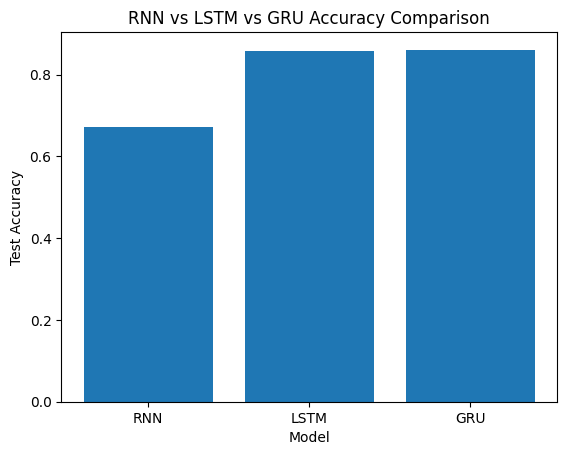

In [ ]:


# -------------------------------
# Accuracy Comparison Plot
# -------------------------------
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM vs GRU Accuracy Comparison")
plt.show()